# Solar Flare Classification 

This study investigates the prediction of solar flares (≥C-class) using Support Vector Classifiers (SVC).  
Two feature sets are compared:
1. **Standardized features (SFs)** from the SHARP dataset (`X_feat`)
2. **Standardized Physics-Informed Features (SPIFs)** — composite quantities derived from physical intuition (`X_op`)

Both a **linear kernel** and an **RBF kernel** SVC are evaluated, using **TSS** (True Skill Statistic) as the primary metric.  
The dataset is split **temporally**: training on the first 3 550 samples, testing on the remainder.

---


## 1. Imports

In [21]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

In [22]:
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

## 2. Utility Functions

### Data Cleaning

Returns the row indices to drop when a sample has more than `n` zero-valued features.  
This avoids feeding degenerate vectors to the classifier.

## Classification Utilities

Helper functions implement the custom threshold-based classification pipeline:

- **`TSS_function`**: computes TSS and HSS from a confusion matrix
- **`tss_scorer`**: thin wrapper around **`TSS_function`** compatible with scikit-learn's **`make_scorer`**.
- **`T`**: sweeps 100 thresholds τ on the training probability scores and returns the τ* maximising TSS
- **`Y_pred_test`**: applies τ* to test-set scores to produce binary predictions

**TSS** (True Skill Statistic) = TPR − FPR is preferred over accuracy for imbalanced datasets.  
**HSS** (Heidke Skill Score) measures improvement over a random classifier.

In [23]:
def index_drop_null(panel_features,n):
    zero_counts = (panel_features.values == 0.).sum(axis=1)
    index_drop = np.where(zero_counts > n)[0]
    return index_drop

#confusion matrix (Y_train, Y_predicted_training) and TSS
def TSS_function(Y_train, Y_predicted_training):
  cm = confusion_matrix(Y_train, Y_predicted_training)
  tn, fp, fn, tp = cm.ravel()
  TSS = (tp/(tp+fn))-(fp/(tn+fp))
  if ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)) == 0.:

    if (tp * tn - fn * fp) == 0:
        HSS = 0.
    else:
        HSS = -100
  else:
      HSS = 2 * (tp * tn - fn * fp) / ((tp + fn) *(fn + tn) + (tp + fp) * (fp + tn))

  return TSS, HSS, cm, tn, fp, fn, tp


#threshold implementation
def tss_scorer(y_true, y_pred):
    TSS, _, _, _, _, _, _ = TSS_function(y_true, y_pred)
    return TSS

def T(Y_train, p):
  a = min(p)
  b = max(p)
  n_train = len(Y_train)
  print('a: ',a)
  print('b: ',b)
  N_tau = 100
  delta = (b-a)/N_tau
  TSS = 0
  taustar = 0
  tau = np.zeros((N_tau,1))
  TSS_list = np.zeros((N_tau,1))
  TSSstar = -1.
  for j in range(N_tau):
      Y_predicted_training = np.zeros((n_train,1)) 
      tau[j] = a+j*delta
      Y_predicted_training[np.where(p > tau[j])]=1.
      TSS_list[j], HSS, cm, tn, fp, fn, tp = TSS_function(Y_train, Y_predicted_training)
      if TSS_list[j]>TSSstar:
        TSSstar = TSS_list[j]
        taustar = tau[j]

  Y_predicted_training = np.zeros((n_train,1))
  Y_predicted_training[np.where(p > taustar)]=1.

  return taustar, TSSstar, Y_predicted_training

def Y_pred_test(ptest, taustar):
  Y_predicted_test = np.zeros((len(ptest),1))
  Y_predicted_test[np.where(ptest > taustar)]=1.

  return Y_predicted_test

## 3. Data Loading and Cleaning

The dataset `df_tot_class_samples.csv` contains solar active-region samples labelled by the maximum flare class produced within a 24 hour window.

**Cleaning steps:**
- Drop rows where more than 4 of the selected features are exactly zero (unreliable measurements).
- Drop rows with any `NaN`.
- Replace remaining zeros with `1e-16` to avoid log-domain issues.
- Remove outlier rows where `mpil_br/max_length > 3 500` (instrument artefacts).
- Remove rows where `mpil_br/max_length` is still effectively zero after replacement.

**Labels:**
- `Label_C = 1` → C class flare


In [24]:
np.random.seed(26) #42
random.seed(26)

class_flare = 'abovec'
df_tot = pd.read_csv('Data/df_tot_class_samples.csv')

print(df_tot.shape)

features_subset = ['decay_index_br/tot_l_over_hmin', 'decay_index_br/maxl_over_hmin', 'sfunction_blos/zq', 'r_value_br_logr', 'helicity_energy_bvec/abs_tot_dedt_in','sharp_kw/ggt45fract',
                 'sharp_kw/rho/total', 'sharp_kw/hgradbh/total', 'wlsg_br/value_int', 'wlsg_blos/value_int',
                 'mpil_br/max_length', 'sharp_kw/snetjzpp/total', 'TOTUSJZ', 'SAVNCPP',
                 'TOTPOT', 'TOTUSJH', 'ABSNJZH', 'USFLUX', 'R_VALUE','AREA_ACR', 'SHRGT45', 'MEANPOT', 'MEANGBZ'] #'decay_index_br/tot_l_over_hmin', 'decay_index_br/maxl_over_hmin', 'sfunction_blos/zq', 'r_value_br_logr', 

features_subset_2 = ['TOTUSJZ', 'TOTPOT','TOTUSJH','USFLUX','AREA_ACR','MEANPOT','MEANGBZ','wlsg_br/value_int','mpil_br/max_length']#['TOTUSJZ', 'TOTPOT','TOTUSJH','USFLUX','AREA_ACR','MEANPOT','MEANGBZ', 'wlsg_br/value_int','mpil_br/max_length']
 
panel_features_tmp = df_tot[features_subset].astype(float)

#dataset cleaning
index_drop = index_drop_null(panel_features_tmp,4)
df_final = df_tot.drop(index = df_tot.index[index_drop])
df_final = df_final.dropna(axis=0)

#final panel_features
df_final[features_subset] = df_final[features_subset].replace(0.0, 1e-16)
mpil_br = df_final[features_subset_2[-1]].values
idx_max_mpil = np.where(mpil_br >3500.)[0]
print(idx_max_mpil)
df_final = df_final.drop(index=df_final.index[idx_max_mpil])
mpil_br = df_final[features_subset_2[-1]].values
idx_0_mpil = np.where(mpil_br ==1e-16)[0]
print(idx_0_mpil)
df_final = df_final.drop(index=df_final.index[idx_0_mpil])

panel_features = df_final[features_subset]
print(panel_features.shape)

# Label vector C class
Y_C = df_final['Label_C'].values

print('Y_C shape: ', Y_C.shape)

n = (panel_features.shape)[0]
p = (panel_features.shape)[1]

(4766, 216)
[2262]
[ 675  731 1531 1613 1654 1662 1711 1825 2043 2104 2386 2434 2766 4149
 4267]
(4487, 23)
Y_C shape:  (4487,)


## 4. Preprocessing

### 4.1 Standardized Features - SFs

The full feature matrix is stored as `X_feat`. A 9-feature subset (`features_subset_2`) is used for the SVC experiments to limit dimensionality.


In [25]:
#FEATURES
X_feat = panel_features

print(X_feat.shape)

(4487, 23)


### 4.2 Physical Re-Scaling

Before building the SPIFs, each raw quantity is re-scaled to SI-compatible orders of magnitude:

| Variable | Physical Quantity | Scaling |
|---|---|---|
| `current` | Total unsigned vertical current (TOTUSJZ) | — |
| `force` | Magnetic pressure proxy (TOTPOT) | ×10 |
| `helicity` | Total unsigned current helicity (TOTUSJH) | — |
| `flux` | Total unsigned magnetic flux (USFLUX) | ×10⁴ |
| `area` | Active-region area (AREA_ACR) | ×3.04×10¹² |
| `endensity` | Mean magnetic energy density (MEANPOT) | ×10⁻³ |
| `gradient` | Mean vertical field gradient (MEANGBZ) | ×10⁶ |
| `mfield` | Weighted-length signed gradient (wlsg_br) | — |
| `length` | Maximum PIL length (mpil_br) | ×10⁶ |


In [26]:
current = panel_features['TOTUSJZ']
force = panel_features['TOTPOT']*10**(1)
helicity = panel_features['TOTUSJH']
flux = panel_features['USFLUX']* 10**(4)
area = panel_features['AREA_ACR']* 3.04* 10**(12)
endensity = panel_features['MEANPOT']* 10**(-3)
gradient = panel_features['MEANGBZ']* 10**(6)
mfield = panel_features['wlsg_br/value_int']
length = panel_features['mpil_br/max_length']* 10**(6)

### 4.3 Standardized Physics-Informed Features (SPIFs)

Six composite features are constructed by combining the rescaled physical quantities.  
Each SPIF encodes a physically motivated combination:

| Feature | Expression |
|---|---|
| SPIF1 | energy density × PIL length × area |
| SPIF2 | magnetic flux × electric current |
| SPIF3 | force × field² / helicity |
| SPIF4 | helicity × current² × area² / force |
| SPIF5 | helicity × current × area / gradient |
| SPIF6 | gradient × length × current × area |


In [27]:
#OPERATIONS

X_op = pd.DataFrame({
   'SPIF1': endensity * length * area,
   'SPIF2': flux * current ,
   'SPIF3': force * (mfield**2) / helicity ,
   'SPIF4': helicity * (current**2) * (area**2) / force,
   'SPIF5': helicity * current * area / gradient,
   'SPIF6': gradient * length * current * area,
   

})

print(X_op.shape)

(4487, 6)


## 4.4. Temporal Train/Test Split

The dataset is ordered chronologically. The first 3 550 samples form the **training set** (2010-2015) and the remainder the **test set** (2016-2017).  

In [28]:
dataframe_train = df_final.iloc[:3550]
dataframe_test = df_final.iloc[3550:]

#Filtering C samples
dataframe_train = dataframe_train[~
                                  
                                    (dataframe_train['Class max'] == 'C') 
                                  ]

dataframe_test = dataframe_test[~
                             
                                    (dataframe_test['Class max'] == 'C') 
                                  ]

print(dataframe_train.shape)
print(dataframe_test.shape)
dataframe_train


(2741, 216)
(826, 216)


,Unnamed: 0.1,Unnamed: 0,T_REC,NOAA_AR,LON_FWT,TOTUSJZ,SAVNCPP,TOTPOT,TOTUSJH,ABSNJZH,...,lat_hg,long_hg,Label_C,Label_M,NO1,NO2,NO3,NO4,Max flare,Class max
0,0,0,2012.09.15_00:00:00_TAI,11566,63.087154,7.019652e+12,9.303881e+11,4.693975e+22,354.903,39.997,...,21.010899,65.814148,0.0,0.0,1,0,0,0,0.0,0
1,1,1,2012.09.16_00:00:00_TAI,11566,76.199547,2.384834e+12,7.072188e+11,1.808381e+22,127.040,3.161,...,21.065499,79.121002,0.0,0.0,1,0,0,0,0.0,0
2,2,2,2012.09.15_00:00:00_TAI,11569,-13.424920,1.348022e+13,2.254447e+12,2.532876e+23,599.129,30.653,...,-12.648250,-15.764648,0.0,0.0,0,0,1,0,0.0,0
3,3,3,2012.09.16_00:00:00_TAI,11569,-0.225269,1.111488e+13,1.737071e+12,2.459861e+23,516.119,22.084,...,-12.534750,-2.254395,0.0,0.0,0,0,0,1,0.0,0
4,4,4,2012.09.18_00:00:00_TAI,11569,26.514540,1.223143e+13,1.371831e+12,2.062452e+23,554.796,24.139,...,-12.525650,24.765992,0.0,0.0,0,0,0,1,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3751,3762,3762,2016.01.03_00:00:00_TAI,12477,-63.208065,5.257292e+12,6.794113e+11,1.026619e+23,319.929,3.839,...,12.261799,-51.809449,0.0,0.0,1,0,0,0,0.0,0
3752,3763,3763,2016.01.04_00:00:00_TAI,12477,-49.589245,5.282476e+12,6.133816e+11,1.034357e+23,245.159,25.236,...,12.170149,-38.321112,0.0,0.0,1,0,0,0,0.0,0
3753,3764,3764,2016.01.05_00:00:00_TAI,12477,-36.623470,5.565335e+12,7.006083e+11,1.060577e+23,240.976,26.222,...,11.956049,-24.805224,0.0,0.0,1,0,0,0,0.0,0
3756,3767,3767,2016.01.09_00:00:00_TAI,12477,16.300137,3.228031e+12,1.124064e+12,4.775712e+22,145.869,41.875,...,12.083950,28.727986,0.0,0.0,1,0,0,0,0.0,0


### 4.5 Standardization


In [29]:
#train/test indices
train_idx = dataframe_train.index
test_idx  = dataframe_test.index

#Dataset feat e op
X_train_op = X_op.loc[train_idx]
X_test_op  = X_op.loc[test_idx]
features_subset_2 = ['TOTUSJZ', 'TOTPOT','TOTUSJH','USFLUX','AREA_ACR','MEANPOT','MEANGBZ','wlsg_br/value_int','mpil_br/max_length']
X_feat_subset = X_feat[features_subset_2]
X_train_feat = X_feat_subset.loc[train_idx]
X_test_feat  = X_feat_subset.loc[test_idx]


Y_train = df_final.loc[train_idx, 'Label_M'].values
Y_test  = df_final.loc[test_idx, 'Label_M'].values

#Standardization
scaling_op = StandardScaler()
X_train_norm_op = scaling_op.fit_transform(X_train_op)
X_test_norm_op  = scaling_op.transform(X_test_op)

scaling_feat = StandardScaler()
X_train_norm_feat = scaling_feat.fit_transform(X_train_feat)
X_test_norm_feat  = scaling_feat.transform(X_test_feat)

print("Train feat:", X_train_feat.shape, "Test feat:", X_test_feat.shape)
print("Train op:", X_train_op.shape, "Test op:", X_test_op.shape)



Train feat: (2741, 9) Test feat: (826, 9)
Train op: (2741, 6) Test op: (826, 6)


## 4.6 Cross-Validation Setup


In [30]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=3)#, shuffle=False, random_state=26)

## 5. SVC Experiments


### 5.1 SVC with linear kernel on SPIFs

In [31]:
#SVC OPERATIONS with Threshold
#Label C
svc = SVC(probability=True, random_state=26) 
C = np.logspace(1, 3, 10)

param_grid = {
    'C': C,
    'kernel': ['linear']
}

grid_search = GridSearchCV(svc, param_grid, scoring=make_scorer(tss_scorer, greater_is_better=True), cv=cv, verbose=1)
grid_search.fit(X_train_norm_op, Y_train)

best_svc_model = grid_search.best_estimator_

p_train = best_svc_model.predict_proba(X_train_norm_op)[:, 1]
taustar, TSSstar, Y_predicted_training = T(Y_train, p_train)
Y_predicted_training = Y_pred_test(p_train, taustar)

p_test = best_svc_model.predict_proba(X_test_norm_op)[:, 1]
Y_predicted_test = Y_pred_test(p_test, taustar)

TSS, HSS, cm, tn, fp, fn, tp = TSS_function(Y_train, Y_predicted_training)
TSS_test, HSS_test, cm_test, tn_test, fp_test, fn_test, tp_test = TSS_function(Y_test, Y_predicted_test)

print("TSS test:", TSS_test)
print("HSS test:", HSS_test)
print("CM test", cm_test)

TN = cm_test[0, 0]
FP = cm_test[0, 1]
FN = cm_test[1, 0]
TP = cm_test[1, 1]

specificity = TN / (TN + FP)
sensitivity = TP / (TP + FN)
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Specificity: {specificity}")
print(f"Sensibility: {sensitivity}")
print(f"Accuracy: {accuracy}")

print("Best param:", grid_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
a:  0.006750651628452802
b:  0.9999999999999699
TSS test: 0.9680981595092024
HSS test: 0.4469794509965494
CM test [[789  26]
 [  0  11]]
Specificity: 0.9680981595092024
Sensibility: 1.0
Accuracy: 0.9685230024213075
Best param: {'C': 10.0, 'kernel': 'linear'}


### 5.2 SPIFs Importance & Cumulative TSS 

The linear SVC coefficients provide a feature-importance ranking.  
A forward-selection experiment adds SPIFs one by one (in order of decreasing |coefficient|) and tracks the test TSS.  
The shaded region marks the saturation zone where additional SPIFs no longer improve performance.


In [32]:
coeff_svc = best_svc_model.coef_
sorted_indices = np.argsort(np.abs(coeff_svc)[0])[::-1]
print(sorted_indices)
print(coeff_svc)
sorted_feature_names = [f"$SPIF_{{{i + 1}}}$" for i in sorted_indices] 

tss_list = []
added_features = []
C = np.logspace(1, 3, 10)
tss_list_train = []
param_grid = {
    'C': C,
    'kernel': ['linear']
}

for i in range(1, len(sorted_indices) + 1):
    X_train_subset = X_train_norm_op[:, sorted_indices[:i]]
    X_test_subset = X_test_norm_op[:, sorted_indices[:i]]
    grid_search_subset = GridSearchCV(svc, param_grid, scoring=make_scorer(tss_scorer, greater_is_better=True), cv=cv, verbose=1)

    grid_search_subset.fit(X_train_subset, Y_train)
    best_svc_model_subset = grid_search_subset.best_estimator_
    p_train_subset = best_svc_model_subset.predict_proba(X_train_subset)[:, 1]
    taustar_subset, TSSstar_subset, Y_predicted_training_subset = T(Y_train, p_train_subset)
    Y_predicted_training_subset = Y_pred_test(p_train_subset, taustar)

    p_test_subset = best_svc_model_subset.predict_proba(X_test_subset)[:, 1]
    Y_predicted_test_subset = Y_pred_test(p_test_subset, taustar)

    TSS_subset, HSS_subset, cm_subset, tn, fp, fn, tp = TSS_function(Y_train, Y_predicted_training_subset)
    TSS_test_subset, HSS_test_subset, cm_test_subset, tn_test, fp_test, fn_test, tp_test = TSS_function(Y_test, Y_predicted_test_subset)

    print("TSS test:", TSS_test_subset)
    print("HSS test:", HSS_test_subset)
    print("CM test", cm_test_subset)


    print("Best param:", grid_search.best_params_)
    tss_list_train.append(TSS_subset)
    tss_list.append(TSS_test_subset)  
    added_features.append(sorted_feature_names[i - 1])


[5 3 4 1 0 2]
[[-0.18626438 -0.50436819  0.15755307 -1.17927127  1.09990175  2.07207927]]
Fitting 3 folds for each of 10 candidates, totalling 30 fits
a:  0.03703515718443882
b:  0.9999999999999699
TSS test: 0.9656441717791411
HSS test: 0.4281192819346224
CM test [[787  28]
 [  0  11]]
Best param: {'C': 10.0, 'kernel': 'linear'}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
a:  0.015311176572982203
b:  0.9999999999999699
TSS test: 0.9631901840490797
HSS test: 0.4107015457788347
CM test [[785  30]
 [  0  11]]
Best param: {'C': 10.0, 'kernel': 'linear'}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
a:  0.009833560550239156
b:  0.9999999999999699
TSS test: 0.9631901840490797
HSS test: 0.4107015457788347
CM test [[785  30]
 [  0  11]]
Best param: {'C': 10.0, 'kernel': 'linear'}
Fitting 3 folds for each of 10 candidates, totalling 30 fits
a:  0.004284129260433704
b:  0.9999999999999699
TSS test: 0.9779141104294479
HSS test: 0.541139435837294
CM test [[797  18]


TSS after adding feature '$SPIF_{6}$': 0.9656441717791411
TSS after adding feature '$SPIF_{4}$': 0.9631901840490797
TSS after adding feature '$SPIF_{5}$': 0.9631901840490797
TSS after adding feature '$SPIF_{2}$': 0.9779141104294479
TSS after adding feature '$SPIF_{1}$': 0.8943669827105409
TSS after adding feature '$SPIF_{3}$': 0.9680981595092024


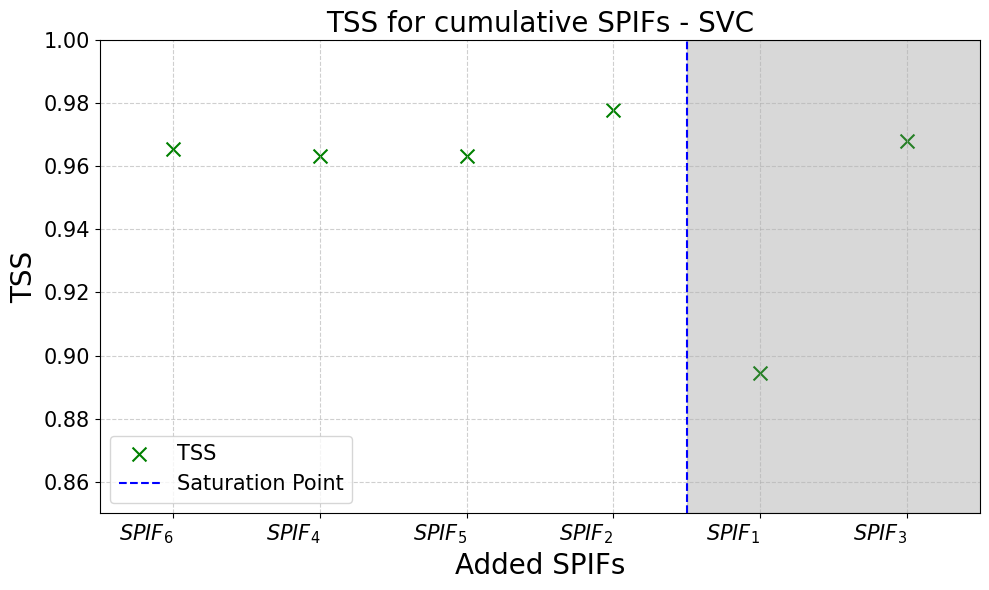

In [33]:
# Print results
sorted_feature_names = [f"$SPIF_{{{i + 1}}}$" for i in sorted_indices]  # Formattazione LaTeX dinamica
for idx, (feature, tss) in enumerate(zip(sorted_feature_names, tss_list)):
    print(f"TSS after adding feature '{feature}': {tss}")

# Plot 
plt.figure(figsize=(10, 6))
plt.scatter(added_features, tss_list, marker='x', color='g', s=100, label='TSS')

if len(added_features) > 3:  
    plt.axvline(x=3.5, color='b', linestyle='--', label='Saturation Point')
    plt.axvspan(3.5, len(added_features), color='gray', alpha=0.3)

plt.xlabel('Added SPIFs', fontsize=20)
plt.ylabel('TSS', fontsize=20)
plt.title('TSS for cumulative SPIFs - SVC', fontsize=20)
plt.xticks(ha='right', fontsize=15) 
plt.yticks(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(left=-0.5, right=len(added_features) - 0.5)
plt.ylim(0.85, 1.)
plt.tight_layout()
plt.legend(loc='lower left', fontsize=15)

### 5.3 SVC with linear kernel on SFs

Same pipeline applied to the 9 standardised features as a baseline comparison.  


In [34]:
#SVC FEATURES
#Label C
svc_feat = SVC(probability=True, random_state=26) #max_iter=5000
C = np.logspace(2, 3, 10)

param_grid = {
    'C': C,
    'kernel': ['linear']
}

grid_search_feat = GridSearchCV(svc_feat, param_grid, scoring=make_scorer(tss_scorer, greater_is_better=True), cv=cv, verbose=1)
grid_search_feat.fit(X_train_norm_feat, Y_train)

best_svc_model_feat = grid_search_feat.best_estimator_

p_train = best_svc_model_feat.predict_proba(X_train_norm_feat)[:, 1]
taustar, TSSstar, Y_predicted_training = T(Y_train, p_train)
Y_predicted_training = Y_pred_test(p_train, taustar)

p_test = best_svc_model_feat.predict_proba(X_test_norm_feat)[:, 1]
Y_predicted_test = Y_pred_test(p_test, taustar)

TSS, HSS, cm, tn, fp, fn, tp = TSS_function(Y_train, Y_predicted_training)
TSS_test, HSS_test, cm_test, tn_test, fp_test, fn_test, tp_test = TSS_function(Y_test, Y_predicted_test)


print("TSS test:", TSS_test)
print("HSS test:", HSS_test)
print("CM test", cm_test)

TN = cm_test[0, 0]
FP = cm_test[0, 1]
FN = cm_test[1, 0]
TP = cm_test[1, 1]

specificity = TN / (TN + FP)
sensitivity = TP / (TP + FN)
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Specificity: {specificity}")
print(f"Sensibility: {sensitivity}")
print(f"Accuracy: {accuracy}")

print("Best param:", grid_search_feat.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
a:  0.0013705832228673744
b:  0.9999999999999699
TSS test: 0.8354712771890686
HSS test: 0.22917112872135362
CM test [[755  60]
 [  1  10]]
Specificity: 0.9263803680981595
Sensibility: 0.9090909090909091
Accuracy: 0.9261501210653753
Best param: {'C': 166.81005372000593, 'kernel': 'linear'}


### 5.4 SVC with gaussian kernel on SPIFs


In [35]:
#SVC SPIFS WITH GAUSSIAN KERNEL

svc = SVC(probability=True, random_state=26)
C = np.logspace(1, 3, 10)

param_grid = {
    'C': C, 
    'kernel': ['rbf'],
    'gamma': ['scale']
}

grid_search = GridSearchCV(svc, param_grid, scoring=make_scorer(tss_scorer, greater_is_better=True), cv=cv, verbose=1)
grid_search.fit(X_train_norm_op, Y_train)

best_svc_model = grid_search.best_estimator_

p_train = best_svc_model.predict_proba(X_train_norm_op)[:, 1]
taustar, TSSstar, Y_predicted_training = T(Y_train, p_train)

p_test = best_svc_model.predict_proba(X_test_norm_op)[:, 1]
Y_predicted_test = Y_pred_test(p_test, taustar)
Y_predicted_training = Y_pred_test(p_train, taustar)

TSS, HSS, cm, tn, fp, fn, tp = TSS_function(Y_train, Y_predicted_training)
TSS_test, HSS_test, cm_test, tn_test, fp_test, fn_test, tp_test = TSS_function(Y_test, Y_predicted_test)


print("TSS test:", TSS_test)
print("HSS test:", HSS_test)
print("CM test", cm_test)

TN = cm_test[0, 0]
FP = cm_test[0, 1]
FN = cm_test[1, 0]
TP = cm_test[1, 1]

specificity = TN / (TN + FP)
sensitivity = TP / (TP + FN)
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Specificity: {specificity}")
print(f"Sensibility: {sensitivity}")
print(f"Accuracy: {accuracy}")

print("Best param:", grid_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
a:  0.004729469429145257
b:  0.9897226284499473
TSS test: 0.9815950920245399
HSS test: 0.586862287429143
CM test [[800  15]
 [  0  11]]
Specificity: 0.9815950920245399
Sensibility: 1.0
Accuracy: 0.9818401937046005
Best param: {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}


### 5.5 SVC with gaussian kernel on SFs


In [36]:
#SVC FEATURES with GAUSSIAN KERNEL

svc = SVC(probability=True, random_state=26)
C = np.logspace(0, 1.5, 100)

param_grid = {
    'C': C,
    'kernel': ['rbf'],
     'gamma': ['scale']
}

grid_search_feat = GridSearchCV(svc, param_grid, scoring=make_scorer(tss_scorer, greater_is_better=True), cv=cv, verbose=1)
grid_search_feat.fit(X_train_norm_feat, Y_train)

best_svc_model_feat = grid_search_feat.best_estimator_

p_train_feat = best_svc_model_feat.predict_proba(X_train_norm_feat)[:, 1]
taustar, TSSstar, Y_predicted_training = T(Y_train, p_train_feat)
Y_predicted_training = Y_pred_test(p_train_feat, taustar)

p_test_feat = best_svc_model_feat.predict_proba(X_test_norm_feat)[:, 1]
Y_predicted_test = Y_pred_test(p_test_feat, taustar)

TSS, HSS, cm, tn, fp, fn, tp = TSS_function(Y_train, Y_predicted_training)
TSS_test, HSS_test, cm_test, tn_test, fp_test, fn_test, tp_test = TSS_function(Y_test, Y_predicted_test)


print("TSS test:", TSS_test)
print("HSS test:", HSS_test)
print("CM test", cm_test)

TN = cm_test[0, 0]
FP = cm_test[0, 1]
FN = cm_test[1, 0]
TP = cm_test[1, 1]

specificity = TN / (TN + FP)
sensitivity = TP / (TP + FN)
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Specificity: {specificity}")
print(f"Sensibility: {sensitivity}")
print(f"Accuracy: {accuracy}")

print("Best param:", grid_search_feat.best_params_)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
a:  0.0005095581569158578
b:  0.9999921379635265
TSS test: 0.85633017289459
HSS test: 0.29699408100893654
CM test [[772  43]
 [  1  10]]
Specificity: 0.947239263803681
Sensibility: 0.9090909090909091
Accuracy: 0.9467312348668281
Best param: {'C': 23.921470814626385, 'gamma': 'scale', 'kernel': 'rbf'}
